# Model Evaluation Pipeline
Performance metrics, SHAP explanations, fairness metrics, and robustness under input noise — for a tabular classification model, ending in a self-contained HTML report.

Dataset: Adult Census Income. Model: `RandomForestClassifier` (same preprocessing as the original notebook).

## 0. Setup

In [1]:
# If running for the first time, uncomment:
!pip install shap fairlearn jinja2 scikit-learn matplotlib pandas numpy --quiet

import base64
import io
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from IPython.display import HTML, display
from jinja2 import Template
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                              precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from fairlearn.metrics import (MetricFrame, demographic_parity_difference,
                                equalized_odds_difference, false_negative_rate,
                                false_positive_rate, selection_rate)

%matplotlib inline

## 1. Load data & train model
Same steps as the original notebook: drop `fnlwgt`, one-hot encode categoricals, train a `RandomForestClassifier`. The only addition is keeping an **unencoded** copy of `sex` before encoding, since the fairness section needs clean group labels rather than one-hot columns.

In [2]:
cols = ['age','workclass','fnlwgt','education','education.num','marital.status',
        'occupation','relationship','race','sex','capital.gain','capital.loss',
        'hours.per.week','native.country','income']

df = pd.read_csv('./datasets/adult.csv', na_values=' ?', skipinitialspace=True).dropna().reset_index(drop=True)

df.drop(columns=['fnlwgt'], inplace=True)
df.head()

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
# Keep an unencoded copy of the protected attribute BEFORE one-hot encoding.
# Fairness metrics need clean group labels ('Male'/'Female'), not one-hot columns.
sex_raw = df['sex'].copy()

df_encoded = pd.get_dummies(df, columns=[
    'workclass', 'education', 'marital.status', 'occupation',
    'relationship', 'race', 'sex', 'native.country'
])

X = df_encoded.drop(columns=['income'])
y = df_encoded['income'].apply(lambda v: 1 if v == '>50K' else 0)

X_train, X_test, y_train, y_test, sex_train, sex_test = train_test_split(
    X, y, sex_raw, test_size=0.3, random_state=42, stratify=y
)

sex_test = sex_test.rename('sex')
print(X_train.shape, X_test.shape)

(22792, 107) (9769, 107)


In [17]:
model = RandomForestClassifier(n_estimators=200, max_depth=14, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print('Model trained.')

Model trained.


In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import classification_report

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      7417
           1       0.78      0.57      0.66      2352

    accuracy                           0.86      9769
   macro avg       0.83      0.76      0.79      9769
weighted avg       0.85      0.86      0.85      9769



In [21]:
def fig_to_base64(fig):
    """Encode a matplotlib figure as base64 PNG (for embedding in the HTML report)."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=110)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')

## 2. Model Performance
Accuracy, precision, recall, F1, ROC-AUC, and a confusion matrix.

In [22]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

performance_metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba),
}

for k, v in performance_metrics.items():
    print(f'{k:>12}: {v:.4f}')

    accuracy: 0.8577
   precision: 0.7761
      recall: 0.5748
    f1_score: 0.6605
     roc_auc: 0.9108


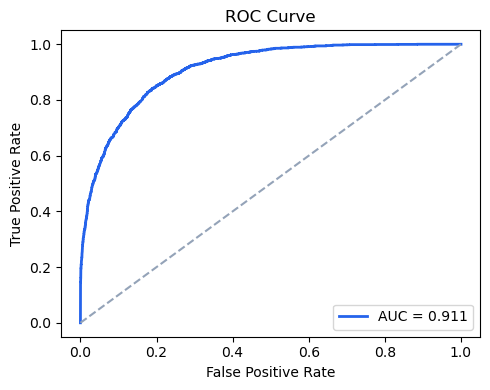

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color='#2563eb', linewidth=2, label=f"AUC = {performance_metrics['roc_auc']:.3f}")
ax.plot([0, 1], [0, 1], linestyle='--', color='#94a3b8')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
fig.tight_layout()
roc_img = fig_to_base64(fig)
plt.show()

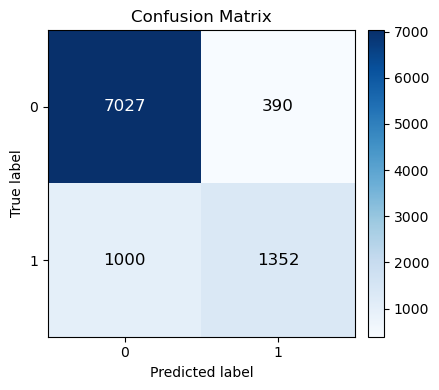

In [24]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=12)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
cm_img = fig_to_base64(fig)
plt.show()

## 3. SHAP Explanations
Global feature importance (beeswarm summary plot) plus a few local explanations for individual predictions. Uses `TreeExplainer`, which is fast and exact for tree-based models like `RandomForestClassifier`.

In [25]:
shap_background = X_train.sample(min(200, len(X_train)), random_state=42)
shap_explain_set = X_test.sample(min(300, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(shap_explain_set)

# Normalize output shape across SHAP versions to the positive-class array
if isinstance(shap_values, list):
    shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

print(shap_values.shape)

(300, 107)


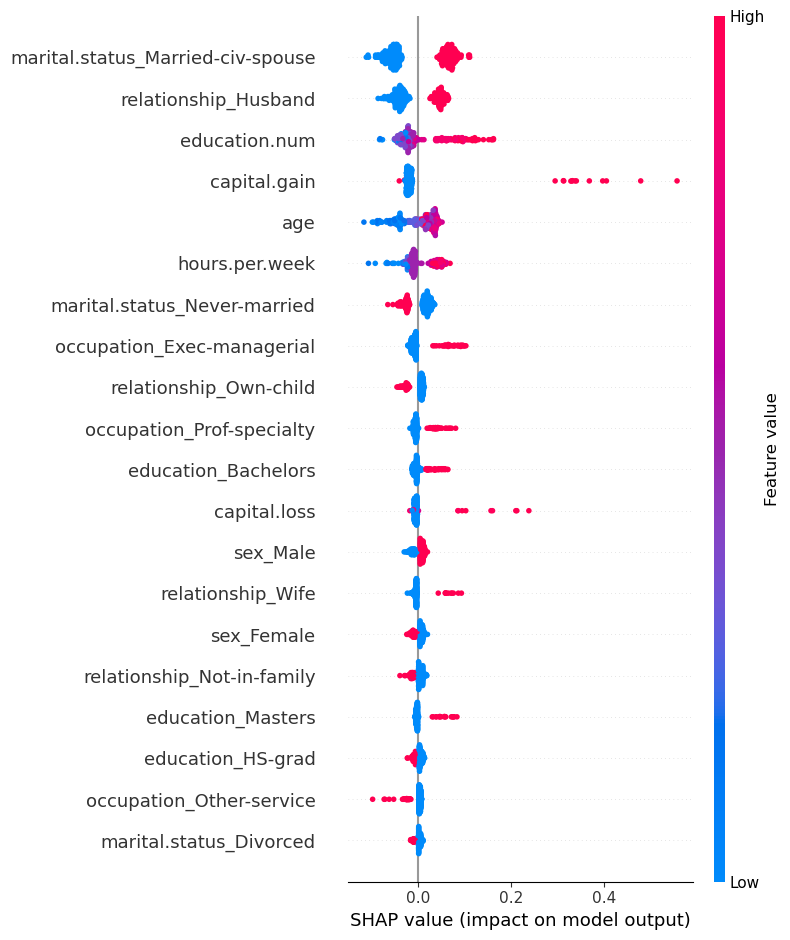

In [26]:
fig = plt.figure(figsize=(7, 5))
shap.summary_plot(shap_values, shap_explain_set, show=False)
fig = plt.gcf()
fig.tight_layout()
summary_img = fig_to_base64(fig)
plt.show()

In [27]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features = sorted(zip(shap_explain_set.columns, mean_abs_shap), key=lambda t: -t[1])[:15]

pd.DataFrame(top_features, columns=['feature', 'mean_abs_shap_value'])

,feature,mean_abs_shap_value
0,marital.status_Married-civ-spouse,0.062310
1,relationship_Husband,0.044226
2,education.num,0.041394
3,capital.gain,0.035524
4,age,0.031393
5,hours.per.week,0.025015
6,marital.status_Never-married,0.022289
7,occupation_Exec-managerial,0.017902
8,relationship_Own-child,0.011511
9,occupation_Prof-specialty,0.011155


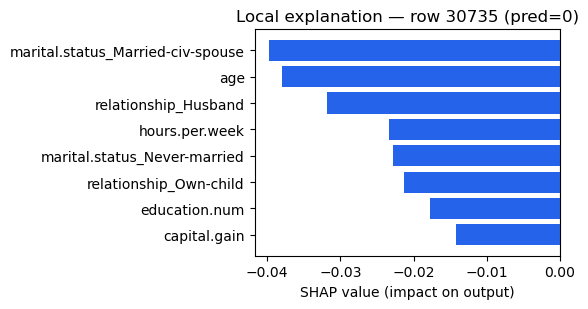

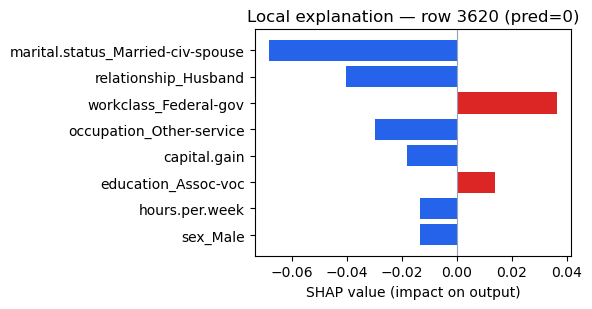

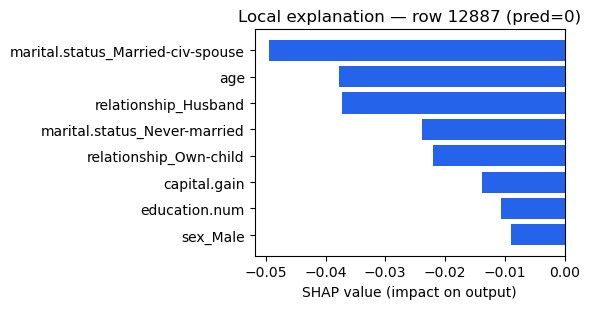

In [28]:
# Local explanations for a handful of individual predictions
local_examples = []
rng = np.random.RandomState(7)
pick_idx = rng.choice(len(shap_explain_set), size=3, replace=False)
local_preds = model.predict(shap_explain_set)

for i in pick_idx:
    row = shap_explain_set.iloc[i]
    sv = shap_values[i]
    order = np.argsort(-np.abs(sv))[:8]
    fig, ax = plt.subplots(figsize=(6, 3.2))
    feats = [shap_explain_set.columns[j] for j in order][::-1]
    vals = [sv[j] for j in order][::-1]
    colors = ['#dc2626' if v > 0 else '#2563eb' for v in vals]
    ax.barh(feats, vals, color=colors)
    ax.axvline(0, color='#94a3b8', linewidth=0.8)
    ax.set_title(f'Local explanation — row {row.name} (pred={local_preds[i]})')
    ax.set_xlabel('SHAP value (impact on output)')
    fig.tight_layout()
    plt.show()
    local_examples.append({'index': int(row.name), 'prediction': int(local_preds[i]), 'img': fig_to_base64(fig)})

## 4. Fairness Metrics
Group fairness across the `sex` attribute, using `fairlearn`: demographic parity difference, equalized odds difference, and disparate impact ratio (the "four-fifths rule" — a ratio above 0.8 is the common threshold for low disparity).

In [29]:
mf = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'selection_rate': selection_rate,
        'false_positive_rate': false_positive_rate,
        'false_negative_rate': false_negative_rate,
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sex_test,
)

group_table = mf.by_group
group_table['n'] = sex_test.value_counts()
group_table

,accuracy,selection_rate,false_positive_rate,false_negative_rate,n
sex,,,,,
Female,0.930037,0.071206,0.018144,0.494286,3216
Male,0.822219,0.230887,0.074269,0.413087,6553


In [30]:
dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=sex_test)
eod = equalized_odds_difference(y_test, y_pred, sensitive_features=sex_test)

sel_rates = mf.by_group['selection_rate']
disparate_impact = sel_rates.min() / sel_rates.max() if sel_rates.max() > 0 else float('nan')

print(f'Demographic parity difference: {dpd:.4f}')
print(f'Equalized odds difference:     {eod:.4f}')
print(f'Disparate impact ratio:        {disparate_impact:.4f}  (>0.8 is the four-fifths rule threshold)')

Demographic parity difference: 0.1597
Equalized odds difference:     0.0812
Disparate impact ratio:        0.3084  (>0.8 is the four-fifths rule threshold)


## 5. Robustness Under Noise
Injects Gaussian noise into numeric input features at increasing intensities (as a fraction of each column's standard deviation), re-runs predictions, and measures how much accuracy/F1 degrade.

In [31]:
noise_levels = (0.0, 0.05, 0.10, 0.20, 0.35)
numeric_columns = [c for c in X_test.columns
                    if pd.api.types.is_numeric_dtype(X_test[c]) and X_test[c].nunique() > 2]
print('Perturbing:', numeric_columns)

stds = X_test[numeric_columns].std()
rng = np.random.RandomState(42)

robustness_results = []
for level in noise_levels:
    X_noisy = X_test.copy()
    if level > 0:
        for col in numeric_columns:
            noise = rng.normal(loc=0.0, scale=level * (stds[col] if stds[col] > 0 else 1.0), size=len(X_noisy))
            X_noisy[col] = X_noisy[col] + noise
    y_pred_noisy = model.predict(X_noisy)
    robustness_results.append({
        'noise_level': level,
        'accuracy': accuracy_score(y_test, y_pred_noisy),
        'f1_score': f1_score(y_test, y_pred_noisy, zero_division=0),
    })

baseline_acc = robustness_results[0]['accuracy']
for r in robustness_results:
    r['accuracy_drop'] = baseline_acc - r['accuracy']

robustness_df = pd.DataFrame(robustness_results)
robustness_df

Perturbing: ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']


,noise_level,accuracy,f1_score,accuracy_drop
0,0.00,0.857713,0.660479,0.000000
1,0.05,0.855973,0.656578,0.001740
2,0.10,0.854745,0.651779,0.002969
3,0.20,0.853209,0.643815,0.004504
4,0.35,0.843382,0.624816,0.014331


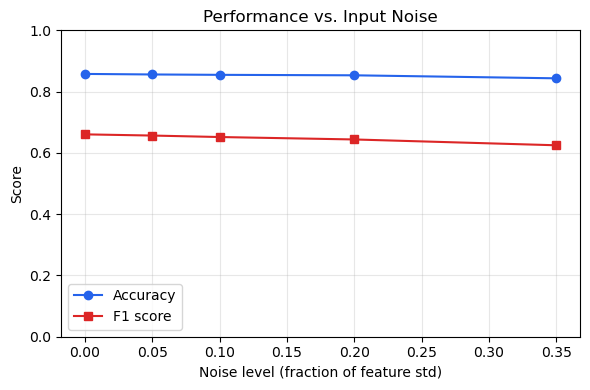

In [32]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(robustness_df['noise_level'], robustness_df['accuracy'], marker='o', color='#2563eb', label='Accuracy')
ax.plot(robustness_df['noise_level'], robustness_df['f1_score'], marker='s', color='#dc2626', label='F1 score')
ax.set_xlabel('Noise level (fraction of feature std)')
ax.set_ylabel('Score')
ax.set_title('Performance vs. Input Noise')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
robustness_img = fig_to_base64(fig)
plt.show()

## 6. Generate HTML Report
Assembles everything above into a single self-contained HTML file (charts embedded as base64, no external dependencies).

In [34]:
REPORT_TEMPLATE = """
<!DOCTYPE html><html lang="en"><head><meta charset="UTF-8">
<title>{{ report_title }}</title>
<style>
  :root { --ink:#1e293b; --muted:#64748b; --line:#e2e8f0; --bg-card:#f8fafc;
          --good:#16a34a; --warn:#d97706; --bad:#dc2626; }
  * { box-sizing: border-box; }
  body { font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
         color: var(--ink); max-width: 980px; margin: 0 auto; padding: 40px 24px 80px; line-height: 1.5; }
  .section{
    background:#fff;
    border:1px solid #e5e7eb;
    border-radius:14px;
    padding:24px;
    margin:32px 0;
    box-shadow:0 3px 12px rgba(0,0,0,.05);
}
  h1 { font-size: 28px; margin-bottom: 4px; }
  .subtitle { color: var(--muted); font-size: 14px; margin-bottom: 36px; }
  h2 { font-size: 20px; border-bottom: 2px solid var(--line); padding-bottom: 8px; margin-top: 48px; }
  h3 { font-size: 16px; margin-top: 24px; }
  .metric-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(140px, 1fr)); gap: 12px; margin: 20px 0; }
  .metric-card { background: var(--bg-card); border: 1px solid var(--line); border-radius: 10px; padding: 14px 16px; }
  .metric-card .label { font-size: 12px; color: var(--muted); text-transform: uppercase; letter-spacing: .03em; }
  .metric-card .value { font-size: 24px; font-weight: 600; margin-top: 4px; }
  .img-row { display: flex; gap: 20px; flex-wrap: wrap; margin: 20px 0; }
  .img-row img { max-width: 460px; width: 100%; border: 1px solid var(--line); border-radius: 8px; }
  table{
    border-collapse:collapse;
    overflow:hidden;
    border-radius:12px;
}

thead{
    background:#1e40af;
    color:white;
}

th{
    color:white;
    font-size:13px;
}

tbody tr:nth-child(even){
    background:#f8fafc;
}

tbody tr:hover{
    background:#eff6ff;
}
 .note{
    background:#eff6ff;
    border-left:5px solid #2563eb;
    padding:15px;
    border-radius:10px;
    color:#334155;
    margin-top:15px;
}
.section-desc{
    color:#475569;
    margin:10px 0 22px;
    font-size:15px;
}

.explanation{
    background:#f8fafc;
    border:1px solid #e2e8f0;
    padding:18px;
    border-radius:10px;
    margin:20px 0;
}

.explanation ul{
    margin:8px 0 0 20px;
}

.explanation li{
    margin-bottom:8px;
}
  .local-example { border: 1px solid var(--line); border-radius: 10px; padding: 12px; margin-bottom: 16px; }
  footer { margin-top: 60px; color: var(--muted); font-size: 12px; text-align: center; }
.hero{
    background:linear-gradient(135deg,#1d4ed8,#2563eb);
    color:white;
    padding:35px;
    border-radius:16px;
    margin-bottom:35px;
}

.hero h1{
    margin:0;
    color:white;
}

.hero p{
    margin:10px 0 20px;
    opacity:.95;
}

.hero-info{
    display:flex;
    gap:25px;
    flex-wrap:wrap;
    font-size:14px;
}


.metric-card{
    background:white;
    border-left:5px solid #2563eb;
    border-radius:12px;
    padding:18px;
    box-shadow:0 2px 8px rgba(0,0,0,.05);
    transition:.2s;
}

.metric-card:hover{
    transform:translateY(-3px);
}
</style></head><body>

<div class="hero">
    <h1>{{ report_title }}</h1>

    <p>
        Comprehensive evaluation of the trained machine learning model,
        including predictive performance, explainability,
        fairness assessment and robustness analysis.
    </p>

    <div class="hero-info">
        <span><b>Generated:</b> {{ generated_at }}</span>
        <span><b>Model:</b> {{ model_name }}</span>
        <span><b>Test Samples:</b> {{ test_set_size }}</span>
    </div>
</div>

<div class="section">
  <h2>1. Model Performance</h2>

  <p class="section-desc">
    This section summarizes the predictive performance of the trained model using standard
    classification metrics. Higher values generally indicate better predictive ability.
  </p>

  <div class="metric-grid">
  {% for label, value in performance_metrics.items() %}
    <div class="metric-card"><div class="label">{{ label.replace('_',' ') }}</div><div class="value">{{ "%.3f"|format(value) }}</div></div>
  {% endfor %}
  </div>
  <div class="img-row">
    <img src="data:image/png;base64,{{ cm_img }}">
    <img src="data:image/png;base64,{{ roc_img }}">
  </div>
</div>

<div class="explanation">
<b>Interpretation</b>

<ul>
<li><b>Accuracy</b> measures the overall percentage of correct predictions.</li>
<li><b>Precision</b> measures how many positive predictions are actually correct.</li>
<li><b>Recall</b> measures how many actual positive samples were correctly identified.</li>
<li><b>F1-score</b> balances precision and recall into a single metric.</li>
<li><b>ROC-AUC</b> measures the model's ability to distinguish between classes. Values closer to 1 indicate better discrimination.</li>
</ul>

</div>

<div class="section">
  <h2>2. SHAP Explanations</h2>
  <p class="section-desc">

  SHAP (SHapley Additive exPlanations) explains how each feature contributes
  to the model's predictions. Global explanations summarize the most influential
  features across the dataset, while local explanations show why an individual
  prediction was made.

  </p>

  <h3>Global feature importance</h3>
  <div class="img-row"><img src="data:image/png;base64,{{ summary_img }}"></div>
  <table><tr><th>#</th><th>Feature</th><th>Mean |SHAP value|</th></tr>
  {% for name, val in top_features %}<tr><td>{{ loop.index }}</td><td>{{ name }}</td><td>{{ "%.4f"|format(val) }}</td></tr>{% endfor %}
  </table>
  <h3>Local explanations</h3>
  {% for ex in local_examples %}
  <div class="local-example"><strong>Row {{ ex.index }}</strong> — predicted class: {{ ex.prediction }}
  <div class="img-row"><img src="data:image/png;base64,{{ ex.img }}"></div></div>
  {% endfor %}

  <div class="note">

  Features with larger mean absolute SHAP values have greater influence on the
  model's predictions across the test dataset.

  </div>
</div>

<div class="section">
  <h2>3. Fairness Metrics</h2>
    <p class="section-desc">

  Fairness analysis evaluates whether the model treats different demographic groups
  consistently. Lower disparity indicates that predictions are more equitable across
  protected groups.

  </p>
  <p class="note">Protected attribute: <strong>{{ fairness_attribute }}</strong></p>
  <div class="metric-grid">
    <div class="metric-card"><div class="label">Demographic parity diff.</div><div class="value">{{ "%.3f"|format(dpd) }}</div></div>
    <div class="metric-card"><div class="label">Equalized odds diff.</div><div class="value">{{ "%.3f"|format(eod) }}</div></div>
    <div class="metric-card"><div class="label">Disparate impact ratio</div><div class="value">{{ "%.3f"|format(disparate_impact) }}</div></div>
  </div>
  <p class="note">Rule of thumb: parity/odds differences near 0 and a disparate impact ratio above 0.8 suggest low disparity between groups.</p>
  <table><tr><th>Group</th><th>N</th><th>Accuracy</th><th>Selection rate</th><th>FPR</th><th>FNR</th></tr>
  {% for group, row in group_table.iterrows() %}
  <tr><td>{{ group }}</td><td>{{ row.n }}</td><td>{{ "%.3f"|format(row.accuracy) }}</td>
  <td>{{ "%.3f"|format(row.selection_rate) }}</td><td>{{ "%.3f"|format(row.false_positive_rate) }}</td>
  <td>{{ "%.3f"|format(row.false_negative_rate) }}</td></tr>
  {% endfor %}
  </table>
</div>

<div class="explanation">

<ul>

<li><b>Demographic Parity Difference:</b> Values close to 0 indicate similar positive prediction rates across groups.</li>

<li><b>Equalized Odds Difference:</b> Measures whether prediction errors are distributed equally. Lower values indicate fairer performance.</li>

<li><b>Disparate Impact Ratio:</b> Values close to 1 indicate equal treatment. Ratios below 0.8 may indicate potential bias.</li>

</ul>

</div>

<div class="section">
  <h2>4. Robustness Under Noise</h2>
  <p class="section-desc">

  Robustness testing evaluates how model performance changes when random Gaussian
  noise is added to the numerical input features. A robust model should maintain
  high predictive performance despite moderate input perturbations.

  </p>
  <div class="img-row"><img src="data:image/png;base64,{{ robustness_img }}"></div>
  <table><tr><th>Noise level</th><th>Accuracy</th><th>F1 score</th><th>Accuracy drop vs. baseline</th></tr>
  {% for row in robustness_results %}
  <tr><td>{{ "%.0f%%"|format(row.noise_level * 100) }}</td><td>{{ "%.3f"|format(row.accuracy) }}</td>
  <td>{{ "%.3f"|format(row.f1_score) }}</td><td>{{ "%.3f"|format(row.accuracy_drop) }}</td></tr>
  {% endfor %}
  </table>
  <div class="note">

    A small decrease in accuracy and F1-score indicates that the model is resilient
    to noisy inputs and is more likely to generalize well in real-world environments.

  </div>
</div>
<footer>Model evaluation pipeline report</footer>
</body></html>
"""

template = Template(REPORT_TEMPLATE)
html = template.render(
    report_title='Model Evaluation Report',
    generated_at=datetime.now().strftime('%Y-%m-%d %H:%M'),
    model_name='RandomForestClassifier (Adult Income)',
    test_set_size=len(X_test),
    performance_metrics=performance_metrics,
    cm_img=cm_img,
    roc_img=roc_img,
    summary_img=summary_img,
    top_features=top_features,
    local_examples=local_examples,
    fairness_attribute='sex',
    dpd=dpd, eod=eod, disparate_impact=disparate_impact,
    group_table=group_table,
    robustness_img=robustness_img,
    robustness_results=robustness_results,
    numeric_columns=numeric_columns,
)

with open('evaluation_report.html', 'w', encoding='utf-8') as f:
    f.write(html)

print('Report written to evaluation_report.html')

Report written to evaluation_report.html
